# 📝 Actividad de Evaluación: Análisis Exploratorio de Portafolios (10%)

**Instrucciones:**
1. Resuelve cada uno de los puntos solicitados utilizando código de Python limpio y ordenado.
2. No olvides acompañar cada visualización con su respectiva **interpretación analítica** (recuerda la regla de oro: qué observas y qué significa).
3. Puedes realizar esta actividad de forma individual o en parejas (según las indicaciones del docente).

---

## 🏦 Paso 1: Selección y Descarga de Datos

1. Selecciona **3 activos financieros** diferentes a los utilizados en la clase (evita usar AAPL, MSFT, GOOGL, AMZN o NVDA).
2. Descarga los datos históricos utilizando `yfinance` para el periodo del **1 de enero de 2024** al **1 de enero de 2026**.
3. Muestra las primeras 5 filas del DataFrame resultante para validar la descarga.

In [13]:
# Escribe aquí tu código para descargar los datos de tus 3 activos elegidos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# Configuración visual básica
sns.set_theme(style="whitegrid")

# Para que los gráficos aparezcan dentro del notebook
%matplotlib inline

yf.Ticker = ["BAC", "ORCL", "UPS"]

precios = yf.download(
    activos,
    start="2024-01-01",
    end="2026-01-01",
    auto_adjust=True
)

[*********************100%***********************]  3 of 3 completed


## 📈 Paso 2: Análisis de Precios de Cierre y Normalización

1. Filtra y extrae únicamente los precios de cierre (`Close`).
2. Grafica en una sola figura la evolución temporal de los precios originales de tus 3 activos.
3. Realiza la normalización (base 100 en el primer registro) y grafica nuevamente las series en otra figura.

### 💬 Pregunta de interpretación #1:
Al comparar ambos gráficos (precios reales vs. precios normalizados), ¿por qué es metodológicamente más correcto utilizar el gráfico normalizado para comparar el rendimiento histórico de los activos? Explica la diferencia en el comportamiento visual observado.

Index(['BAC', 'ORCL', 'UPS'], dtype='object', name='Ticker')
Observaciones: 502
Columnas: 15
Primera fecha: 2024-01-02 00:00:00
Última fecha: 2025-12-31 00:00:00
Price   Ticker
Close   BAC       0
        ORCL      0
        UPS       0
High    BAC       0
        ORCL      0
        UPS       0
Low     BAC       0
        ORCL      0
        UPS       0
Open    BAC       0
        ORCL      0
        UPS       0
Volume  BAC       0
        ORCL      0
        UPS       0
dtype: int64
MultiIndex([( 'Close',  'BAC'),
            ( 'Close', 'ORCL'),
            ( 'Close',  'UPS'),
            (  'High',  'BAC'),
            (  'High', 'ORCL'),
            (  'High',  'UPS'),
            (   'Low',  'BAC'),
            (   'Low', 'ORCL'),
            (   'Low',  'UPS'),
            (  'Open',  'BAC'),
            (  'Open', 'ORCL'),
            (  'Open',  'UPS'),
            ('Volume',  'BAC'),
            ('Volume', 'ORCL'),
            ('Volume',  'UPS')],
           names=['Price', 'T

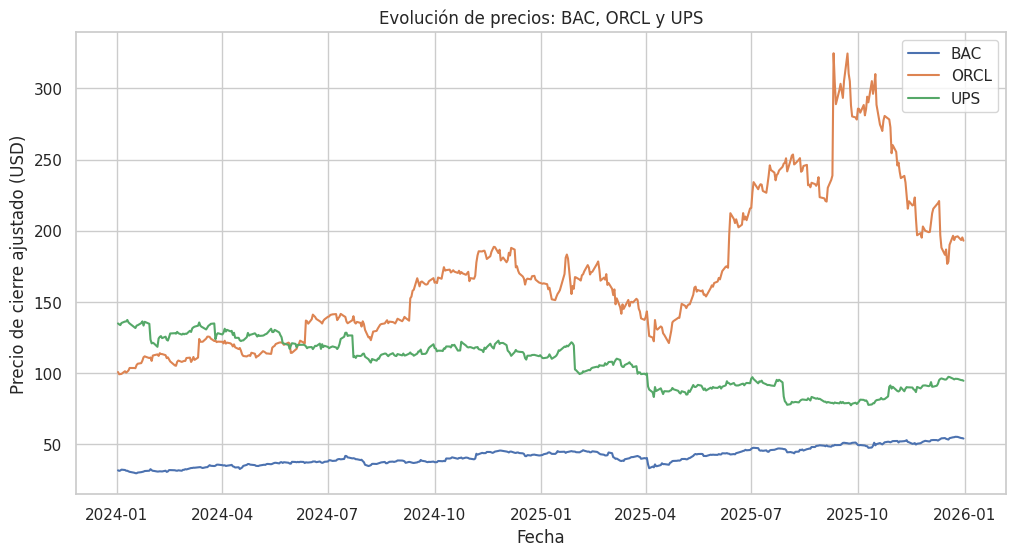

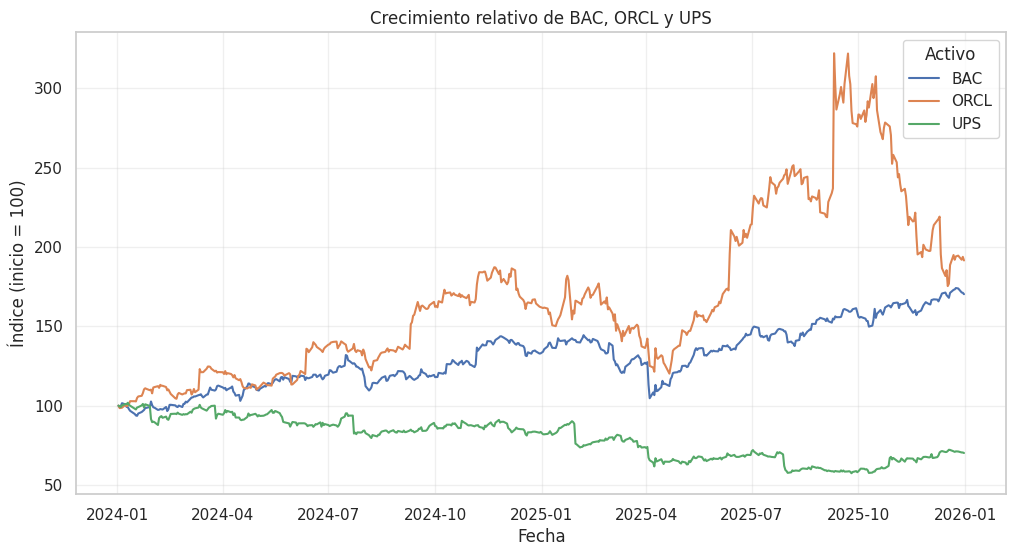

In [18]:
# 1. Extraer los precios de cierre

print(precios.columns.get_level_values("Ticker").unique())

filas, columnas = precios.shape

print(f"Observaciones: {filas}")
print(f"Columnas: {columnas}")

print(f"Primera fecha: {precios.index.min()}")
print(f"Última fecha: {precios.index.max()}")

faltantes = precios.isna().sum()

print(faltantes)

print(precios.columns)
print(precios.columns.names)

# 2. Graficar precios originales

cierre = precios["Close"]

fig, ax = plt.subplots(figsize=(12, 6))

for activo in activos:
    ax.plot(cierre.index, cierre[activo], label=activo)

ax.set_title("Evolución de precios: BAC, ORCL y UPS")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio de cierre ajustado (USD)")
ax.legend()
plt.show()

# 3. Normalizar y graficar en base 100

cierre_normalizado = cierre / cierre.iloc[0] * 100

fig, ax = plt.subplots(figsize=(12, 6))

for activo in activos:
    ax.plot(
        cierre_normalizado.index,
        cierre_normalizado[activo],
        label=activo
    )

ax.set_title("Crecimiento relativo de BAC, ORCL y UPS")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice (inicio = 100)")
ax.legend(title="Activo")
ax.grid(True, alpha=0.3)

plt.show()


Pregunta de interpretación #1
Es más recomendable usar los precios normalizados porque permite ver el comportamiento de los activos desde el comienzo del periodo y su crecimiento. Mientras que los precios originales muestran solo el precio en esa fecha.

## 🔄 Paso 3: Cálculo y Distribución de Rendimientos

1. Calcula los rendimientos diarios de los activos y elimina los valores nulos (`NaN`).
2. Genera un **histograma* para el activo que consideres que haya sido el más volátil.
3. Diseña un **Boxplot** comparativo que muestre los rendimientos diarios de tus 3 activos simultáneamente.

### 💬 Pregunta de interpretación #2:
Observando el Boxplot y el Histograma:
- ¿Qué activo presenta la mayor dispersión (caja más amplia o bigotes más largos) y qué te dice esto sobre su riesgo?
- ¿Identificas valores atípicos (outliers)? ¿Qué representan estos puntos en el contexto de la historia económica reciente de estas empresas?

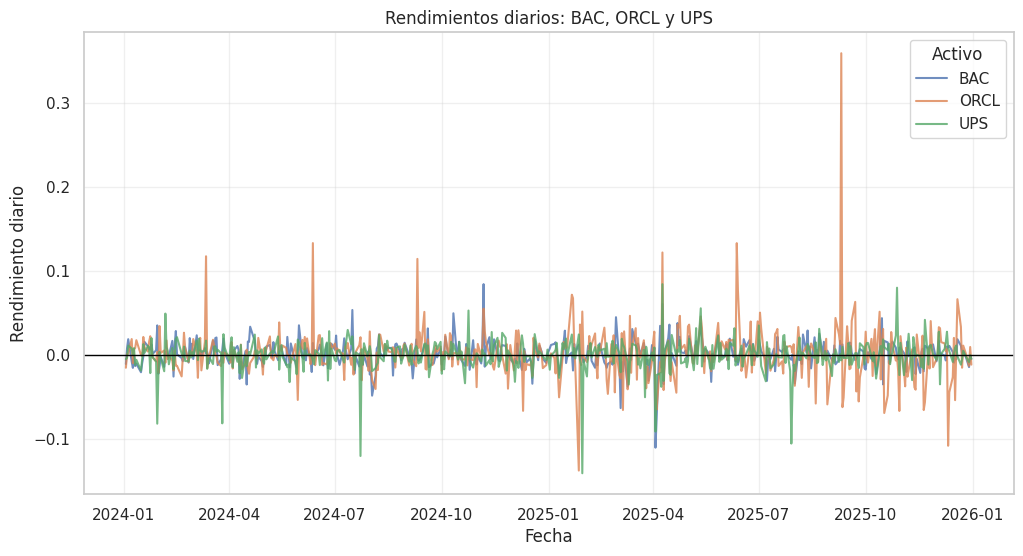

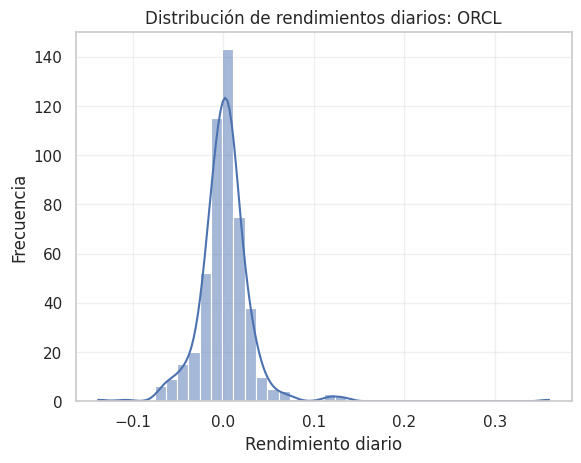

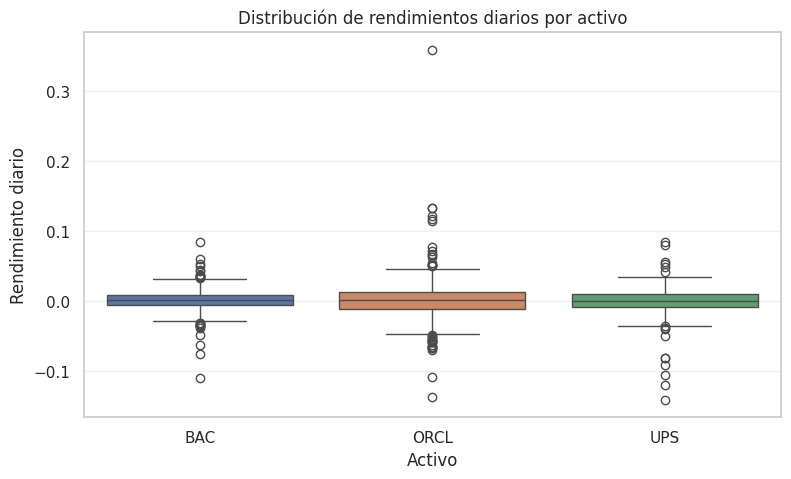

In [23]:
# 1. Calcular rendimientos


rendimientos = cierre.pct_change()
rendimientos = rendimientos.dropna()

rendimientos.head()

fig, ax = plt.subplots(figsize=(12, 6))

for activo in activos:
    ax.plot(
        rendimientos.index,
        rendimientos[activo],
        label=activo,
        alpha=0.8
    )

ax.axhline(0, color="black", linewidth=1)
ax.set_title("Rendimientos diarios: BAC, ORCL y UPS")
ax.set_xlabel("Fecha")
ax.set_ylabel("Rendimiento diario")
ax.legend(title="Activo")
ax.grid(True, alpha=0.3)

plt.show()

# 2. Histograma con el activo más volátil
activo_elegido = "ORCL"

sns.histplot(
    data=rendimientos,
    x=activo_elegido,
    bins=40,
    kde=True
)

plt.title(f"Distribución de rendimientos diarios: {activo_elegido}")
plt.xlabel("Rendimiento diario")
plt.ylabel("Frecuencia")
plt.grid(True, alpha=0.3)

plt.show()

# 3. Boxplot comparativo de rendimientos

plt.figure(figsize=(9, 5))

sns.boxplot(data=rendimientos)

plt.title("Distribución de rendimientos diarios por activo")
plt.xlabel("Activo")
plt.ylabel("Rendimiento diario")
plt.grid(True, axis="y", alpha=0.3)

plt.show()

¿Qué activo presenta la mayor dispersión (caja más amplia o bigotes más largos) y qué te dice esto sobre su riesgo?
El activo que presenta mayor dispersión es ORCL, lo que significa que este activo tiene mayor riesgo a la hora de invertir ya que sus precios varían mucho en el tiempo.


## 📊 Paso 4: Asociación y Correlación

1. Calcula la matriz de correlación de Pearson para los rendimientos de tus 3 activos.
2. Grafica un **mapa de calor (Heatmap)**.

### 💬 Pregunta de interpretación #3:
- ¿Existe alguna correlación fuerte (cercana a 1 o -1) entre alguno de tus activos?
- Si tuvieras que armar un portafolio de inversión buscando la **diversificación** (minimizar el riesgo conjunto), ¿qué par de activos elegirías de acuerdo a tus resultados y por qué?

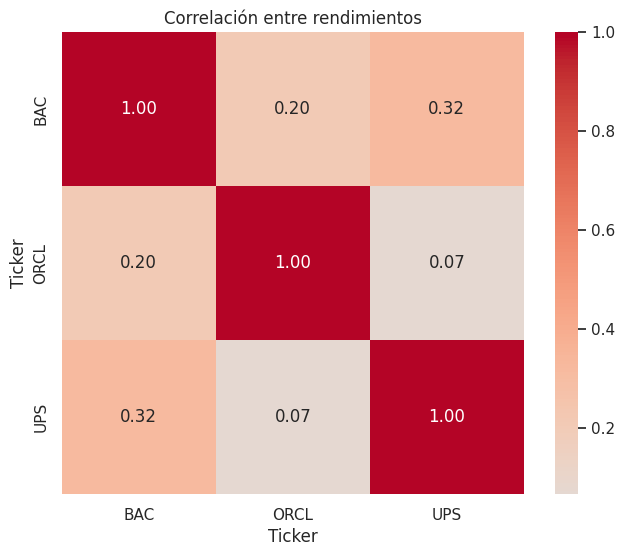

In [25]:
# 1. Calcular matriz de correlación

correlacion = rendimientos.corr()

correlacion

# 2. Dibujar el Heatmap utilizando Seaborn

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlación entre rendimientos")

plt.show()

¿Existe alguna correlación fuerte (cercana a 1 o -1) entre alguno de tus activos?
Hay una correlación positiva entre UPS y BAC DE 0,32 lo que muestra que los activos algunos días pueden tener comportamientos similares. Sin embargo, es moderado.
Si tuvieras que armar un portafolio de inversión buscando la diversificación (minimizar el riesgo conjunto), ¿qué par de activos elegirías de acuerdo a tus resultados y por qué?
ORCL y UPS ya que su correlación es muy baja. Por lo tanto, hay menor riesgo a la hora de invertir.

## 🧮 Paso 5: Estadísticas Descriptivas y Conclusión

1. Genera un DataFrame de resumen estadístico que incluya para cada activo: Media, Mediana, Desviación Estándar, Mínimo y Máximo de los rendimientos diarios.
2. Escribe una breve conclusión final dirigida a un inversionista ficticio, interpretando los estadísticos clave obtenidos.

In [26]:
# Generar resumen de estadísticas descriptivas (Media, Mediana, Desviación estándar, Mínimo y Máximo)
resumen = pd.DataFrame({
    "Media": rendimientos.mean(),
    "Mediana": rendimientos.median(),
    "Desviación estándar": rendimientos.std(),
    "Mínimo": rendimientos.min(),
    "Máximo": rendimientos.max()
})

resumen

,Media,Mediana,Desviación estándar,Mínimo,Máximo
Ticker,,,,,
BAC,0.001185,0.001217,0.015617,-0.110633,0.084288
ORCL,0.001750,0.001991,0.030972,-0.137909,0.359488
UPS,-0.000526,0.000000,0.018767,-0.141127,0.084204


Como recomendación invertiría en BAC porque es un activo que se mantiene estable en el tiempo y no hay mucho riesgo de que sus precios cambien drasticamente, UPS es un activo que no aporta mucho al portafolio por lo que siento que no vale tanto la pena invertir y ORCL es un activo muy volatil por lo cual tiene un mayor riesgo de perdidas a través del tiempo.